# 3. Experiments with custom GBM

В этом ноутбуке исследуется, как различные техники, реализованные в кастомном градиентном бустинге — subsampling, feature subsampling, GOSS, бинаризация, target encoding категориальных признаков, DART и early stopping — влияют на качество модели по сравнению с базовой версией.

In [176]:
# нужные импорты
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
sns.set(style='darkgrid')

from sklearn.metrics import roc_auc_score

Подгрузим данные, сформируем валидационную выборку, на которой и будет проверять эффективность/неэффективность добавленных имплементаций

In [177]:
# для начала подгрузим данные 
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


train = pd.read_csv('data/adult.data', names=columns, skipinitialspace=True, na_values=['?'])
test = pd.read_csv('data/adult.test', names=columns, skipinitialspace=True, na_values=['?'], skiprows=1)
test['income'] = test['income'].str.rstrip('.') # тк в тесте точка на конце

In [178]:
# и заполним пропуски как мы решили это делать в EDA
train.fillna('Unknown', inplace=True)
test.fillna('Unknown', inplace=True)

In [179]:
# выделим целевую переменную
y_train = train['income'].apply(lambda x: x=='>50K').astype(int)
X_train = train.drop(columns='income', axis=1)

# отделим валидационную выборку
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [180]:
# обработаем категориальные признаки и отмасштабируем числовые до добавления имплементации для работы с категориальными признаками 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# взяли с EDA
cat_features = train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Исключаем целевую переменную
if 'income' in cat_features:
    cat_features.remove('income')

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scaling', StandardScaler(), num_features)
])

X_train_scaled = column_transformer.fit_transform(X_train)
X_val_scaled = column_transformer.transform(X_val)

In [181]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [182]:
%autoreload 2

from boosting import Boosting

In [183]:
# baseline на кастомном бустинге 
boosting = Boosting(
    verbose=False,
    random_state=42,
    n_estimators = 200, # по дефолту их 20, что очень мало, поэтому добавим
    base_model_params = {"max_depth": 3, "min_samples_leaf": 20} # похожие на дефолтные параметры из sklearn
)

# преобразуем таргет в 1/-1 
y_train_gbm = y_train.apply(lambda x: 1 if x == 1 else -1)
y_val_gbm = y_val.apply(lambda x: 1 if x == 1 else -1)

boosting.fit(X_train_scaled, y_train_gbm)
print(f'Valid ROC-AUC {boosting.score(X_val_scaled, y_val):.4f}')

Valid ROC-AUC 0.9059


### 1. Борьба с переобучением

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. 
Для этого в модель __boosting.py__ добавлены следующие параметры:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из model.history
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из model.history

непосредственно в метод __model.fit()__ были добавлены:
- `eval_set: Tuple[np.ndarray] | None = None` — валидационная выборка X_valid: np.ndarray, y_valid: np.ndarray, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус early_stopping_rounds, т.е самой лучшей, после которой качество только падает

In [184]:
# добавили eval_set + early_stopping_rounds + метрику val_roc_auc по которой будем отслеживать переобучение
boosting = Boosting(
    verbose=False,
    random_state=42,
    n_estimators=500, 
    base_model_params = {"max_depth": 3, "min_samples_leaf": 20},
    early_stopping_rounds=20,
    eval_metric='val_roc_auc',
    learning_rate=0.1
) 

boosting.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), use_best_model=True)
print(f'Val ROC-AUC {boosting.score(X_val_scaled, y_val):.4f}')

Val ROC-AUC 0.8971


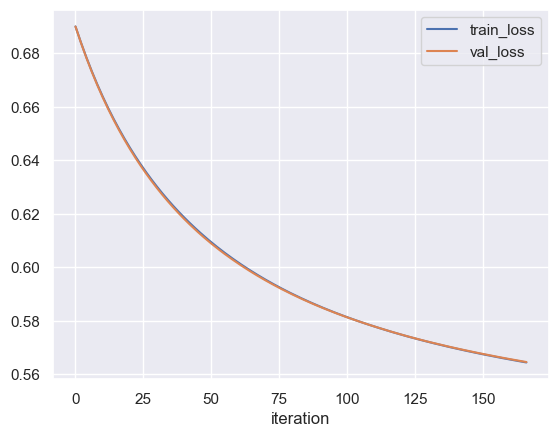

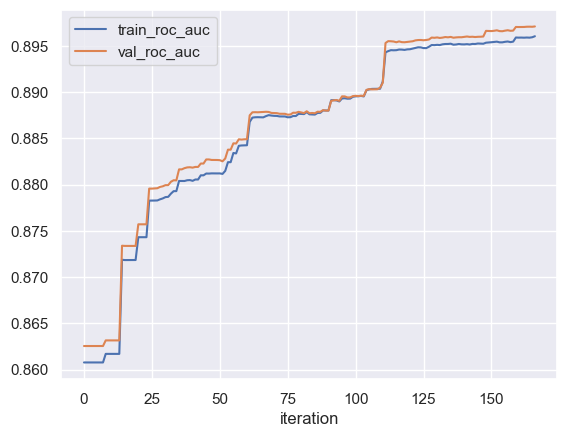

In [185]:
boosting.plot_history(["train_loss", "val_loss"])
boosting.plot_history(["train_roc_auc", "val_roc_auc"])

В данном примере можем наблюдать то, что `early_stopping_rounds` работает и обучение прервалось на 140-вой итерации, так как качество ухудхалось на протяжении 20 итераций подряд. Скорее всего это связано с тем что базовые модели - неглубокие деревья - очень слабые

Попробуем взять модели мощнее, но так как они больше склонны к переобучению, зададим `early_stopping_rounds`= 15

In [186]:
boosting = Boosting(
    verbose=False,
    random_state=42,
    n_estimators=500, 
    base_model_params = {"max_depth": 5, "min_samples_leaf": 20},
    early_stopping_rounds=15,
    learning_rate=0.1, 
    eval_metric='val_roc_auc',
) 

boosting.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), use_best_model=True)
print(f'Val ROC-AUC {boosting.score(X_val_scaled, y_val):.4f}')

Val ROC-AUC 0.9113


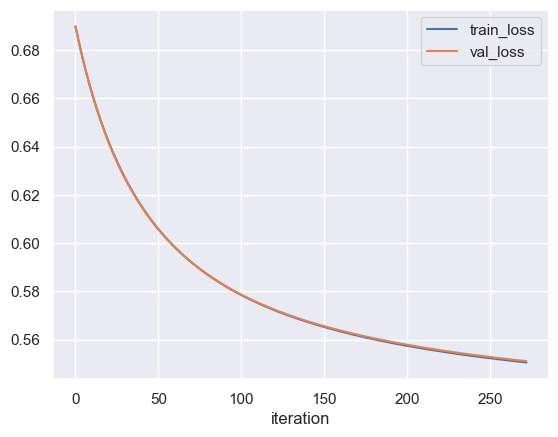

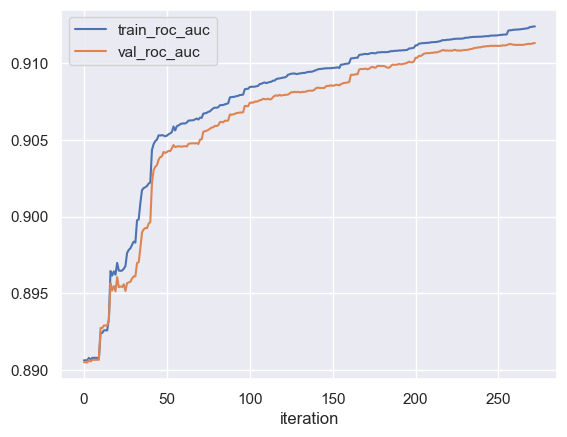

In [187]:
boosting.plot_history(["train_loss", "val_loss"])
boosting.plot_history(["train_roc_auc", "val_roc_auc"])

За счет более сложных базовых моделей получилось выбить лучшее качество на валидации

### 2. Обработка категориальных признаков

Ранее мы обрабатывали категориальные признаки через OHE, теперь попробуем работать с ними напрямую. CatBoost в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий. Реализуем энкодер для обработки категориальных признаков отдельным классом и привяжем его к `Boosting`

> Основная идея обработки категориальных признаков в CatBoost в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

In [188]:
# преобразуем чтобы можно было подать в CatEncoder, тк он работает с np.array
cat_features_idx = [X_train.columns.get_loc(col) for col in cat_features]

X_train = X_train.to_numpy()
X_val = X_val.to_numpy()

In [189]:
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()

y_train = np.where(y_train_np == 1, 1, -1)
y_val = np.where(y_val_np == 1, 1, -1)

In [190]:
boosting = Boosting(
    random_state=42,
    verbose=False,
    cat_features=cat_features_idx,
    n_estimators=500,
    learning_rate=0.1,
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    eval_metric="val_roc_auc", 
    early_stopping_rounds=15
)

boosting.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val), 
    use_best_model=True
)

print(f"Train ROC-AUC {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting.score(X_val, y_val):.4f}")

Train ROC-AUC 0.9317
Valid ROC-AUC 0.9283


Видимо более "умный" учет категориальных признаков хорошо сказался на качестве модели

### 3. Бутстрап

Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Попробуем сделать то же самое в бустинге?

> Идея, которая за этим стоит проста - бустинги легко переобучаются. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

Добавим следующие параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку. \
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$ 
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

In [191]:
boosting = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    subsample=0.6,
    early_stopping_rounds=15,
    bootstrap_type="Bernoulli",
    cat_features=cat_features_idx,          
    verbose=False
)

boosting.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9297
Valid ROC-AUC: 0.9275


In [192]:
boost_bayes = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    cat_features=cat_features_idx,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    early_stopping_rounds=15
)

boost_bern = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    bootstrap_type="Bernoulli",
    cat_features=cat_features_idx,         
    subsample=0.75,
    early_stopping_rounds=15
)

boost_bayes.fit(X_train, y_train, use_best_model=True)
boost_bern.fit(X_train, y_train, use_best_model=True)

print(f'Bayesian val ROC-AUC: {boost_bayes.score(X_val, y_val):.4f}')
print(f'Bernoulli val ROC-AUC: {boost_bern.score(X_val, y_val):.4f}')

Bayesian val ROC-AUC: 0.9281
Bernoulli val ROC-AUC: 0.9286


Заметим, что обе версии бутстрапа без дополнительного перебора параметров дали схожий прирост в сравнении с бейзлайном 

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Добавим параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [193]:
boosting = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    early_stopping_rounds=15,
    rsm=0.5,
    cat_features=cat_features_idx,      
    verbose=False
)

boosting.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9321
Valid ROC-AUC: 0.9291


Такая рандомизация подмножества признаков для обучения в комбинации с учетом категориальных признаков показывает лучшее качество в сравнении с бейзлайном

### 4. GOSS

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты.

Добавим:
- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

In [194]:
boosting_goss = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=15,
    learning_rate=0.1,
    goss=True,
    goss_k=0.2,
    subsample=0.3,       
    cat_features=cat_features_idx,
    verbose=False
)
boosting_goss.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boosting_goss.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_goss.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9314
Valid ROC-AUC: 0.9285


Если добавлять GOSS, то без перебора параметров он дает чуть лучшее качество на валидации в сравнении с бейзлайном

### 5. Бинаризация

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию.

> Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее. Беда лишь в новых данных, которые могут оказаться вне бина. Фактически мотивация вновь та же, что у бутстрапа

Реализуем квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

In [195]:
boosting = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=15,
    learning_rate=0.1,        
    quantization_type = 'uniform',
    cat_features=cat_features_idx,
    bootstrap_type="Bernoulli",
    subsample=0.75,
    verbose=False
    )
boosting.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9311
Valid ROC-AUC: 0.9281


In [196]:
boosting = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=15,  
    learning_rate=0.1,      
    quantization_type = 'quantile',
    cat_features=cat_features_idx,
    bootstrap_type="Bernoulli",
    subsample=0.75,
    verbose=False
    )
boosting.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9298
Valid ROC-AUC: 0.9271


Видим что оба типа бинаризации смогли улучшить метрику на валидации в сравнении с бейзлайном, но это все равно чуть слабее чем когда мы просто добавили умный учет категориальных признаков

### 6. Важность признаков

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить, после этого нормировать значения, чтобы они суммировались в единицу.

Добавим:
- `feature_importances_` — атрибут, который возвращает важность признаков

In [197]:
boosting_quant = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    early_stopping_rounds=15,        
    quantization_type = 'uniform',
    cat_features=cat_features_idx,
    bootstrap_type="Bernoulli",
    subsample=0.75,
    verbose=False
    )
boosting_quant.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
features = boosting_quant.feature_importances_()

In [198]:
features 

array([0.11835854, 0.04626132, 0.04043192, 0.06012009, 0.04962654,
       0.13316087, 0.08342566, 0.11099369, 0.01719879, 0.02641387,
       0.13573511, 0.08586782, 0.07095429, 0.02145149])

Видим что самыми важными признаками оказались: age, marital-status, relationship и capital-gain

### 7. DART

В бустинге каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Это может привести к переобучению, чтобы этого избежать добавим [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Добавим в бустинг:
- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

In [199]:
boost_dart = Boosting(
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},
    n_estimators=500,
    random_state=42,
    learning_rate=0.1,
    early_stopping_rounds=15,
    dart=True,
    dropout_rate=0.05,
    cat_features=cat_features_idx,
    bootstrap_type="Bernoulli",
    subsample=0.75,
    verbose=False
)
boost_dart.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

print(f"Train ROC-AUC: {boost_dart.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boost_dart.score(X_val, y_val):.4f}")

Train ROC-AUC: 0.9117
Valid ROC-AUC: 0.9126


Прирост относительно бейзлайна есть, но это немного хуже прошлых результатов. DART выступает в качестве регуляризации, параметры которой нужно аккуратно подобрать

Соберем все то, что дало прирост относительно бейзлайна и проверим на тесте

In [200]:
boosting = Boosting(
    random_state=42,
    verbose=False,

    n_estimators=500,
    learning_rate=0.1,
    base_model_params={"max_depth": 5, "min_samples_leaf": 20},

    cat_features=cat_features_idx,

    bootstrap_type="Bernoulli",
    subsample=0.75,
    rsm=0.5,

    early_stopping_rounds=15,
    eval_metric="val_roc_auc",
)

boosting.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

In [201]:
# возьмем тестовую выборку 
y_test = test['income'].apply(lambda x: x=='>50K').astype(int)
X_test = test.drop(columns='income', axis=1)

X_test = X_test.to_numpy()
y_test_np = y_test.to_numpy()

y_test = np.where(y_test_np == 1, 1, -1)

print(f"Test ROC-AUC: {boosting.score(X_test, y_test):.4f}")

Test ROC-AUC: 0.9254


В ходе экспериментов было установлено:
- Увеличение глубины базовых деревьев дало основной прирост качества
- Target encoding категориальных признаков существенно улучшил результат
- Bernoulli subsampling и RSM позволили снизить переобучение и дали небольшой прирост
- GOSS и DART не дали значимого улучшения без дополнительной настройки и скорее требуют более тчательного перебора параметров
- Quantization не показал видимых улучшений на данном датасете

Финальная версия кастомного бустинга использует target encoding категориальных признаков, Bernoulli subsampling, feature subsampling через RSM и early stopping. Такая конфигурация показала лучшее качество среди протестированных вариантов и была проверена на отложенной тестовой выборке.